# Analysis: ECB Rate Shock and SME Failures (sectoral)

## Objective
Difference-in-differences on **annual** PME failures: did failures rise more in bank-credit-dependent sectors after the July 2022 ECB hike, vs the 2015-2019 baseline?

Outcome: `log(1 + annual failures)`, with sector fixed effects. Because there are only **nine sectors (clusters)**, ordinary cluster-robust standard errors are unreliable, so inference uses a **wild cluster restricted bootstrap** (Cameron-Gelbach-Miller), which is valid with few clusters.

In [1]:
from pathlib import Path
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ValueWarning
from IPython.display import display

warnings.simplefilter('ignore', ValueWarning)
sys.path.insert(0, str(Path().resolve().parent))
from src import cleaning

Path('../outputs').mkdir(exist_ok=True)
annual = pd.read_csv('../data/processed/sector_panel_annual.csv')
treatment = pd.read_csv('../data/processed/treatment.csv', index_col=0)
s = annual[annual['in_sample']].copy()
s['ly'] = np.log1p(s['failures'])
print('annual obs:', len(s), '| sectors:', s['sector'].nunique(), '| years:', sorted(s['year'].unique()))

annual obs: 72 | sectors: 9 | years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2023), np.int64(2024), np.int64(2025)]


## 1. Main difference-in-differences (with wild cluster bootstrap)

In [2]:
m = smf.ols('ly ~ C(sector) + post + did', data=s).fit(
    cov_type='cluster', cov_kwds={'groups': s['sector']})
wcb = cleaning.wild_cluster_bootstrap_p(
    s, 'ly ~ C(sector) + post + did', 'ly ~ C(sector) + post', 'did', 'sector')
print(f"DiD coefficient: {m.params['did']:+.4f} log ({np.expm1(m.params['did'])*100:+.1f}%)")
print(f"  naive cluster-robust p (9 clusters, unreliable): {m.pvalues['did']:.3f}")
print(f"  wild cluster bootstrap p ({wcb['n_boot']} reps): {wcb['p_boot']:.3f}")

DiD coefficient: -0.1026 log (-9.7%)
  naive cluster-robust p (9 clusters, unreliable): 0.287
  wild cluster bootstrap p (1999 reps): 0.340


**Reading:** the point estimate is negative (bank-dependent sectors did not rise more, if anything less), but the wild cluster bootstrap p-value shows it is **not statistically significant**. With nine sectors the sectoral analysis stays indicative. The territorial analysis (notebook 04, ~100 clusters) carries the inferential weight.

## 2. Robustness: sharp treatment contrast
Top-3 most bank-dependent sectors vs bottom-3, dropping the middle three.

In [3]:
ranked = treatment['bank_dependence'].sort_values(ascending=False)
top3, bottom3 = list(ranked.index[:3]), list(ranked.index[-3:])
sub = s[s['sector'].isin(top3 + bottom3)].copy()
sub['treated_t'] = sub['sector'].isin(top3).astype(int)
sub['did_t'] = sub['treated_t'] * sub['post']
wcb_t = cleaning.wild_cluster_bootstrap_p(
    sub, 'ly ~ C(sector) + post + did_t', 'ly ~ C(sector) + post', 'did_t', 'sector')
print('treated (top3):', top3, '| control (bottom3):', bottom3)
print(f"DiD (tertile): {wcb_t['coef']:+.4f} log ({np.expm1(wcb_t['coef'])*100:+.1f}%), "
      f"wild bootstrap p={wcb_t['p_boot']:.3f}")

treated (top3): ['AZ', 'I', 'PS'] | control (bottom3): ['BE', 'JZ', 'H']
DiD (tertile): -0.1811 log (-16.6%), wild bootstrap p=0.275


## 3. Placebo: fake break inside the baseline
Using only 2015-2019, assign a fake treatment at 2018. A genuine effect should leave this near zero.

In [4]:
b = annual[annual['in_baseline']].copy()
b['ly'] = np.log1p(b['failures'])
b['fake_post'] = (b['year'] >= 2018).astype(int)
b['fake_did'] = b['fake_post'] * b['treated']
wcb_p = cleaning.wild_cluster_bootstrap_p(
    b, 'ly ~ C(sector) + fake_post + fake_did', 'ly ~ C(sector) + fake_post',
    'fake_did', 'sector')
print(f"Placebo DiD: {wcb_p['coef']:+.4f} log, wild bootstrap p={wcb_p['p_boot']:.3f}")

Placebo DiD: -0.0029 log, wild bootstrap p=0.956


## 4. DiD decomposition

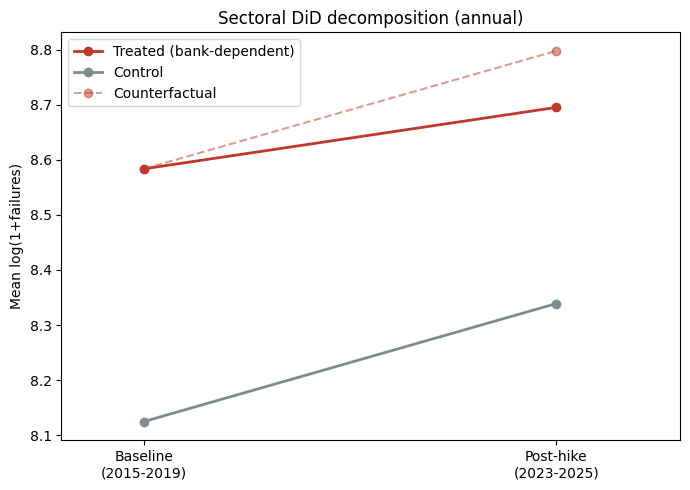

In [5]:
g = s.groupby(['treated', 'post'])['ly'].mean().unstack()
before_t, after_t = g.loc[1, 0], g.loc[1, 1]
before_c, after_c = g.loc[0, 0], g.loc[0, 1]
cf = before_t + (after_c - before_c)
fig, ax = plt.subplots(figsize=(7, 5))
x = [0, 1]
ax.plot(x, [before_t, after_t], 'o-', color='#c0392b', lw=2, label='Treated (bank-dependent)')
ax.plot(x, [before_c, after_c], 'o-', color='#7f8c8d', lw=2, label='Control')
ax.plot(x, [before_t, cf], 'o--', color='#c0392b', lw=1.5, alpha=0.5, label='Counterfactual')
ax.set_xticks(x)
ax.set_xticklabels(['Baseline\n(2015-2019)', 'Post-hike\n(2023-2025)'])
ax.set_ylabel('Mean log(1+failures)')
ax.set_title('Sectoral DiD decomposition (annual)')
ax.legend(loc='upper left')
ax.set_xlim(-0.2, 1.3)
plt.tight_layout()
plt.savefig('../outputs/did_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

## Results summary

On annual non-overlapping data with wild-cluster-bootstrap inference, the bank-credit-dependent sectors show a negative but **not statistically significant** change in failures after the hike. The sharp-contrast variant points the same way and the placebo finds nothing. With nine sectors this analysis stays indicative. The territorial analysis provides the better-powered test.

**Limitations specific to this analysis:**
1. **Nine sectors:** even with the wild cluster bootstrap, power is low.
2. **Treatment proxy:** bank-debt share stands in for rate exposure (maturity split unavailable by sector).
3. **Industry and personal services:** dependence is a simple mean of two FIBEN sub-sectors (no debt weights).